# 6 — Market Anomaly Detection

**Optional Task C**: Identify unusual patterns in historical data.

- Extreme return events (Z-score > 3)
- Volume spikes (vs 60-day rolling baseline)
- Volatility regime classification (high / normal / low)
- Timeline of market events

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from src.preprocess import load_all_stocks, load_metadata

sns.set_style('whitegrid')
%matplotlib inline

## 6.1 Extreme Return Detection

In [2]:
stocks = load_all_stocks()
meta = load_metadata()

def detect_return_anomalies(df, threshold=3.0):
    """Flag dates where |return Z-score| > threshold."""
    ret = df['Close'].pct_change().dropna()
    z = (ret - ret.mean()) / ret.std()
    mask = z.abs() > threshold
    anom = df.loc[z.index[mask]].copy()
    # FIX: use index-aligned assignment, not .values
    # .values caused ValueError when ret/z (which drop the first row) are
    # shorter than df, leading to a length mismatch on assignment.
    anom['z_score'] = z[mask]
    anom['daily_return'] = ret[mask]
    return anom

In [3]:
# Count anomalies per stock
anomaly_counts = {}
all_anomalies = []

for sym, df in stocks.items():
    anom = detect_return_anomalies(df)
    anomaly_counts[sym] = len(anom)
    if len(anom) > 0:
        anom['symbol'] = sym
        all_anomalies.append(anom[['Close', 'z_score', 'daily_return', 'symbol']])

all_anom = pd.concat(all_anomalies).sort_index()

print(f'Total anomalous events across all stocks: {len(all_anom)}')
print(f'\nTop 10 most volatile stocks (by anomaly count):')
pd.Series(anomaly_counts).sort_values(ascending=False).head(10)

Total anomalous events across all stocks: 2614

Top 10 most volatile stocks (by anomaly count):


SHREECEM      80
INDUSINDBK    79
ZEEL          77
DRREDDY       74
BAJFINANCE    72
RELIANCE      68
HCLTECH       68
ULTRACEMCO    66
TATASTEEL     64
WIPRO         64
dtype: int64

In [4]:
extreme = (
    all_anom.reset_index()
            .assign(abs_z=lambda x: x['z_score'].abs())
            .nlargest(15, 'abs_z')
)

extreme[['Date', 'symbol', 'daily_return', 'z_score']]

,Date,symbol,daily_return,z_score
1996,2013-07-30,ASIANPAINT,-0.900209,-40.304730
256,2000-07-05,HINDUNILVR,-0.896562,-39.806988
903,2005-09-21,ITC,-0.927342,-37.638840
1917,2010-09-08,BRITANNIA,-0.772636,-36.566068
2061,2014-11-20,SBIN,-0.897921,-33.475836
1947,2011-07-14,HDFCBANK,-0.799202,-33.375726
788,2004-05-12,CIPLA,-0.795261,-32.629280
371,2001-03-14,HEROMOTOCO,-0.794593,-32.516135
2146,2016-10-06,GRASIM,-0.795441,-31.945453
1912,2010-08-18,HDFC,-0.793549,-30.444696


## 6.2 Anomaly Timeline

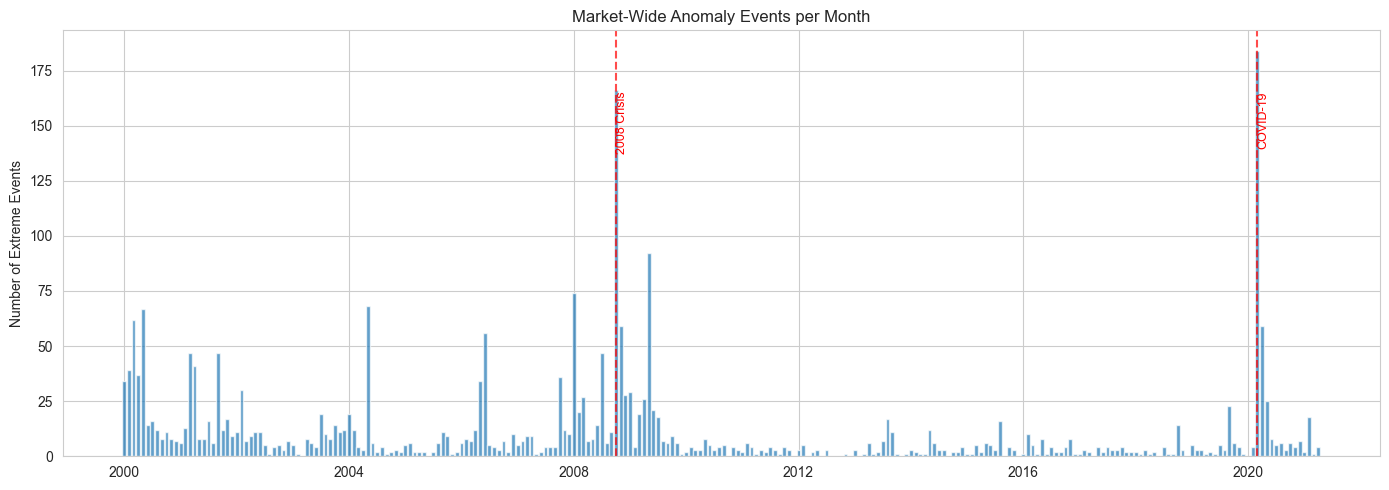

In [5]:
# Aggregate: how many anomalies per month across all stocks?
timeline = all_anom.groupby(all_anom.index.to_period('M')).size()
timeline.index = timeline.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(timeline.index, timeline.values, width=25, alpha=0.7)
ax.set_title('Market-Wide Anomaly Events per Month')
ax.set_ylabel('Number of Extreme Events')

# Mark known events
# FIX: use timeline.values.max() instead of ax.get_ylim()[1] — matplotlib
# finalizes y-limits lazily so get_ylim() returns 1.0 (default) before render.
for date, label in [('2008-10', '2008 Crisis'), ('2020-03', 'COVID-19')]:
    ax.axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.7)
    ax.annotate(label, xy=(pd.Timestamp(date), timeline.values.max() * 0.9),
                fontsize=9, color='red', rotation=90, va='top')

plt.tight_layout()
plt.show()

## 6.3 Volume Spike Detection

RELIANCE: 124 volume spike events


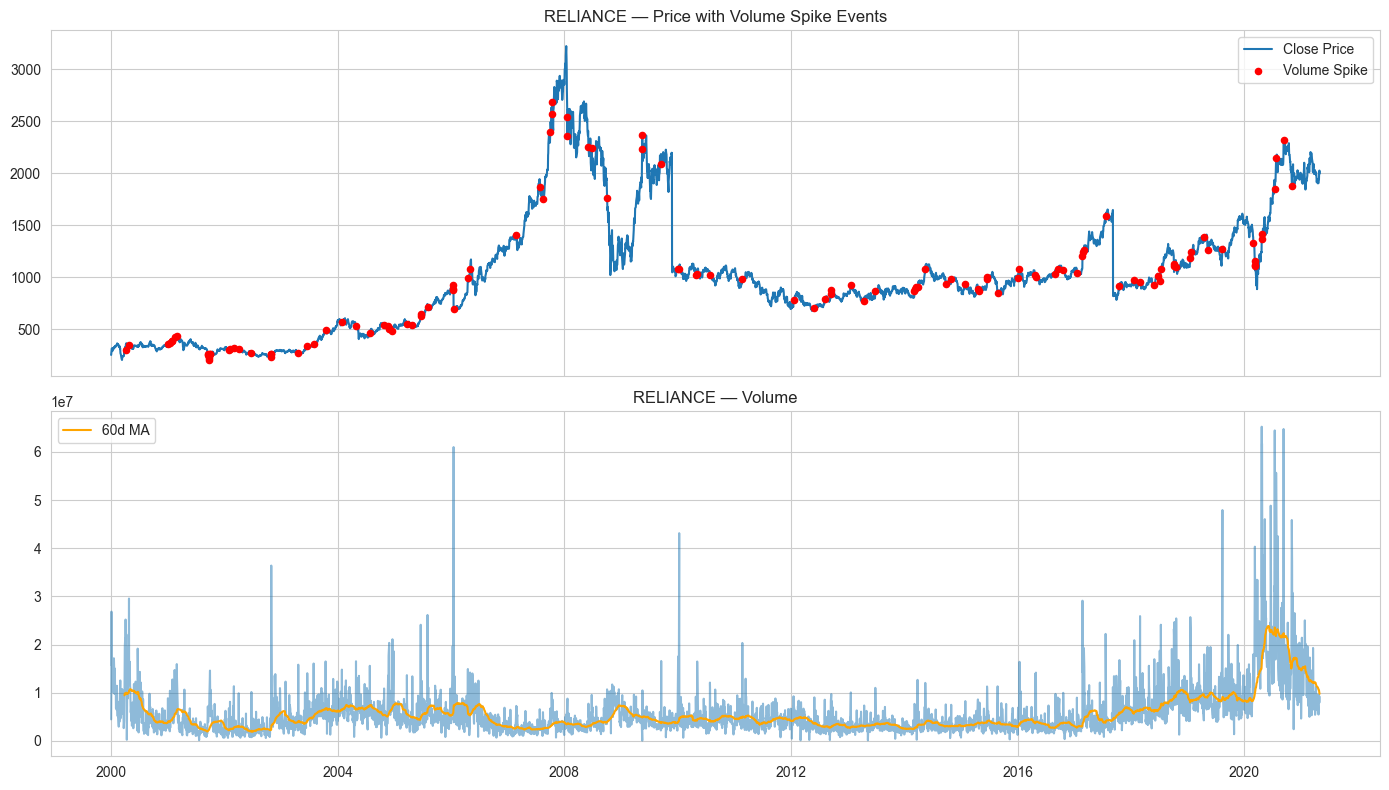

In [6]:
def detect_volume_spikes(df, threshold=3.0):
    """Flag days where volume Z-score (vs 60-day rolling) > threshold."""
    if 'Volume' not in df.columns:
        return pd.DataFrame()
    vol = df['Volume']
    rm = vol.rolling(60).mean()
    rs = vol.rolling(60).std()
    z = ((vol - rm) / rs).dropna()
    mask = z.abs() > threshold
    anom = df.loc[z.index[mask]].copy()
    # FIX: use index-aligned assignment, not .values
    # z is shorter than df (rolling drops first 60 rows), so .values causes length mismatch.
    anom['volume_z'] = z[mask]
    return anom

# Example: RELIANCE
sym = 'RELIANCE'
vol_spikes = detect_volume_spikes(stocks[sym])
print(f'{sym}: {len(vol_spikes)} volume spike events')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(stocks[sym]['Close'], label='Close Price')
if len(vol_spikes) > 0:
    axes[0].scatter(vol_spikes.index, vol_spikes['Close'], color='red', zorder=5, s=20, label='Volume Spike')
axes[0].set_title(f'{sym} — Price with Volume Spike Events')
axes[0].legend()

axes[1].plot(stocks[sym]['Volume'], alpha=0.5)
axes[1].plot(stocks[sym]['Volume'].rolling(60).mean(), color='orange', label='60d MA')
axes[1].set_title(f'{sym} — Volume')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6.4 Volatility Regime Detection

In [7]:
def classify_volatility_regime(df, short=20, long=60):
    """Label each day as high / normal / low volatility."""
    ret = df['Close'].pct_change()
    short_vol = ret.rolling(short).std()
    long_vol = ret.rolling(long).std()
    ratio = (short_vol / long_vol).dropna()

    regime = pd.Series('normal', index=ratio.index)
    regime[ratio > 1.5] = 'high'
    regime[ratio < 0.5] = 'low'
    return ratio, regime

sym = 'TCS'
ratio, regime = classify_volatility_regime(stocks[sym])

print(f'{sym} — Volatility Regime Distribution:')
print(regime.value_counts())

TCS — Volatility Regime Distribution:
normal    3851
low        134
high        94
Name: count, dtype: int64


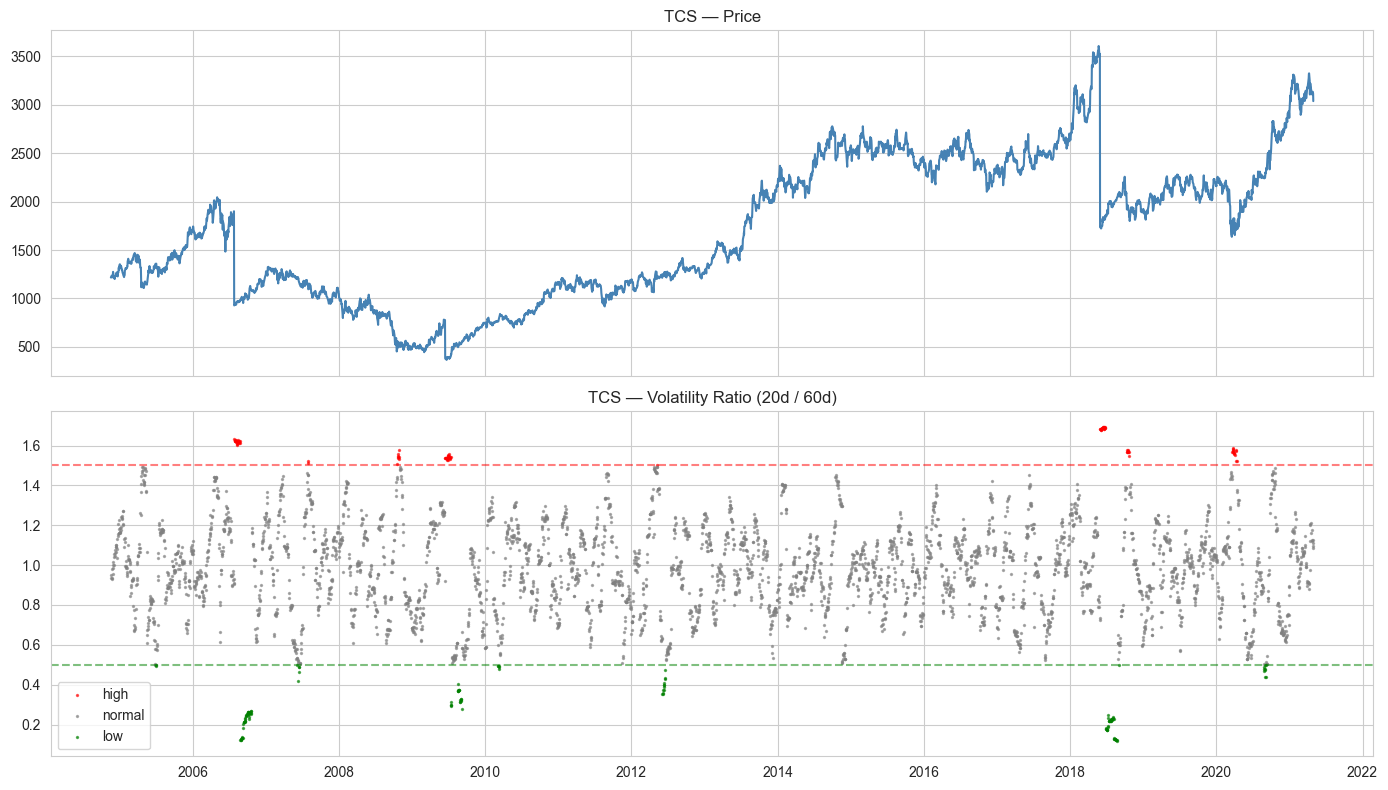

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(stocks[sym]['Close'].loc[ratio.index], color='steelblue')
axes[0].set_title(f'{sym} — Price')

colors = {'high': 'red', 'normal': 'gray', 'low': 'green'}
for reg in ['high', 'normal', 'low']:
    mask = regime == reg
    axes[1].scatter(ratio.index[mask], ratio[mask], c=colors[reg], s=2, label=reg, alpha=0.6)

axes[1].axhline(1.5, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(0.5, color='green', linestyle='--', alpha=0.5)
axes[1].set_title(f'{sym} — Volatility Ratio (20d / 60d)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6.5 Market-Wide High-Volatility Summary

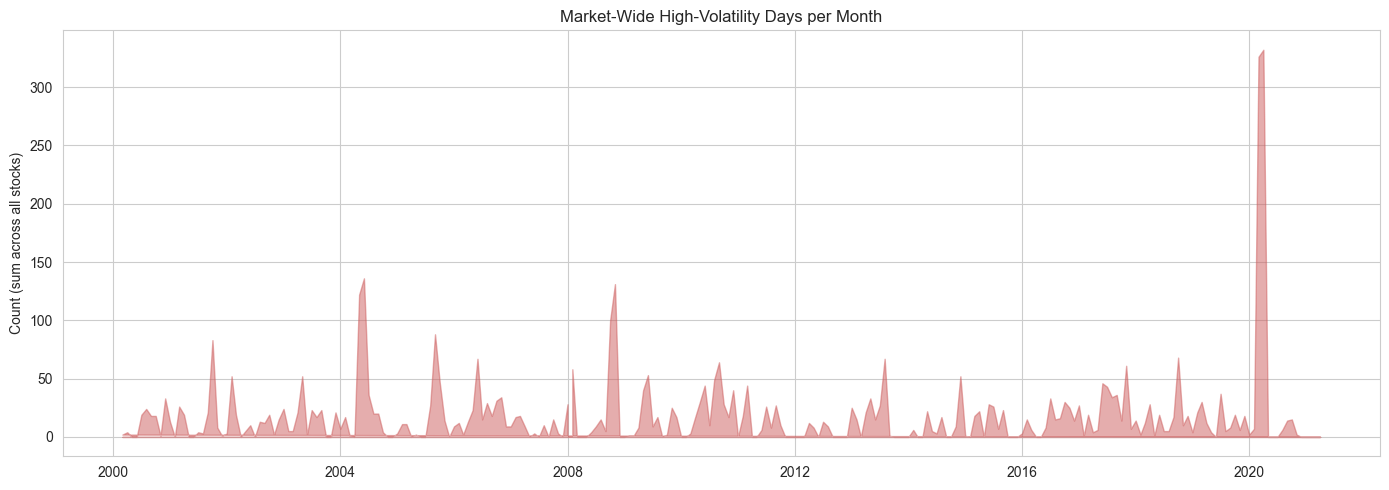

In [9]:
# Count stocks in high-volatility regime per month
high_vol_counts = []
for sym, df in stocks.items():
    _, reg = classify_volatility_regime(df)
    monthly = (reg == 'high').groupby(reg.index.to_period('M')).sum()
    monthly.name = sym
    high_vol_counts.append(monthly)

hv = pd.concat(high_vol_counts, axis=1).sum(axis=1)
hv.index = hv.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(hv.index, hv.values, alpha=0.5, color='indianred')
ax.set_title('Market-Wide High-Volatility Days per Month')
ax.set_ylabel('Count (sum across all stocks)')
plt.tight_layout()
plt.show()

## 6.6 Key Findings

- **Extreme return events** cluster around known crises: 2008 financial crisis, 2020 COVID crash
- **Volume spikes** often precede or coincide with large price moves
- **High-volatility regimes** are transient — markets spend most time in normal regime
- **Anomaly detection** helps identify periods where risk models may underestimate tail risk
- These signals can inform position sizing and portfolio rebalancing decisions